# Signal

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# style of plot
plt.style.use('ggplot')

create one signal

$$
x = A \sin(2\pi f t)
$$

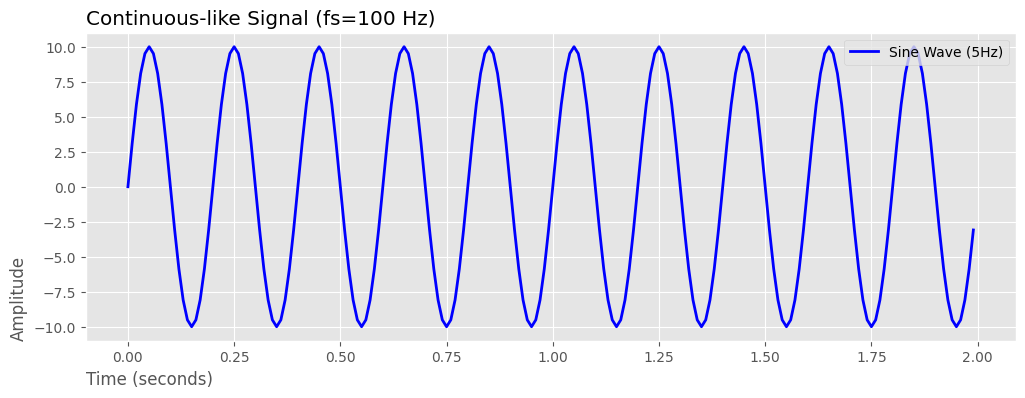

Signal Shape: (200,)
First 10 samples: [ 0.          3.09016994  5.87785252  8.09016994  9.51056516 10.
  9.51056516  8.09016994  5.87785252  3.09016994]


In [3]:
fs = 100 # Sampling rate 100Hz - each 1 second has 100 Samples
duration = 2.0 # long of signal - 2 second
f = 5 # frequency 5Hz
A = 10 # Amplitude


t = np.arange(0, duration, 1/fs) # time
x = A * np.sin(2 * np.pi * f * t) # signal A * sin(2π * f * t)


plt.figure(figsize=(12, 4))
plt.plot(t, x, label='Sine Wave (5Hz)', color='blue', linewidth=2)
plt.title(f'Continuous-like Signal (fs={fs} Hz)', loc="left")
plt.xlabel('Time (seconds)', loc="left")
plt.ylabel('Amplitude', loc="bottom")
plt.grid(True)
plt.legend()
plt.show()

print(f"Signal Shape: {x.shape}")
print(f"First 10 samples: {x[:10]}")

change Sampling rate

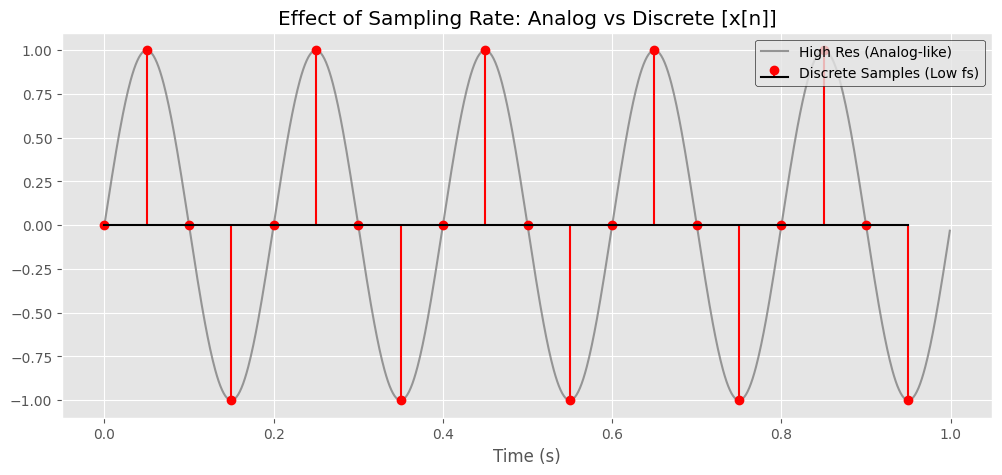

In [4]:
fs_high = 1000  # high quality
fs_low = 20     # low quality

t_high = np.arange(0, 1, 1/fs_high)
t_low = np.arange(0, 1, 1/fs_low)


# signal
x_high = np.sin(2 * np.pi * 5 * t_high)
x_low = np.sin(2 * np.pi * 5 * t_low)


plt.figure(figsize=(12, 5))

plt.plot(t_high, x_high, label='High Res (Analog-like)', color='gray', alpha=0.8)
plt.stem(t_low, x_low, linefmt='r-', markerfmt='ro', basefmt='k', label='Discrete Samples (Low fs)')
plt.title('Effect of Sampling Rate: Analog vs Discrete [x[n]]')
plt.xlabel('Time (s)')
plt.legend(loc="upper right", edgecolor="black")
plt.show()

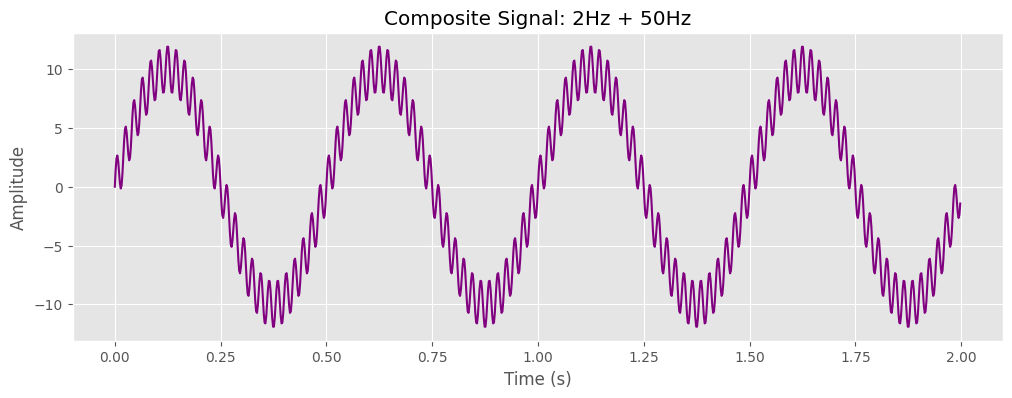

In [5]:
fs = 500
t = np.arange(0, 2, 1/fs)

# سیگنال ۱: فرکانس پایین و دامنه بالا (مثل موج اصلی دریا)
freq1 = 2
amp1 = 10
s1 = amp1 * np.sin(2 * np.pi * freq1 * t)

# سیگنال ۲: فرکانس بالا و دامنه کم (مثل ریزموج‌های روی آب)
freq2 = 50
amp2 = 2
s2 = amp2 * np.sin(2 * np.pi * freq2 * t)

# سیگنال ترکیبی
composite_signal = s1 + s2

plt.figure(figsize=(12, 4))
plt.plot(t, composite_signal, color='purple')
plt.title(f'Composite Signal: {freq1}Hz + {freq2}Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

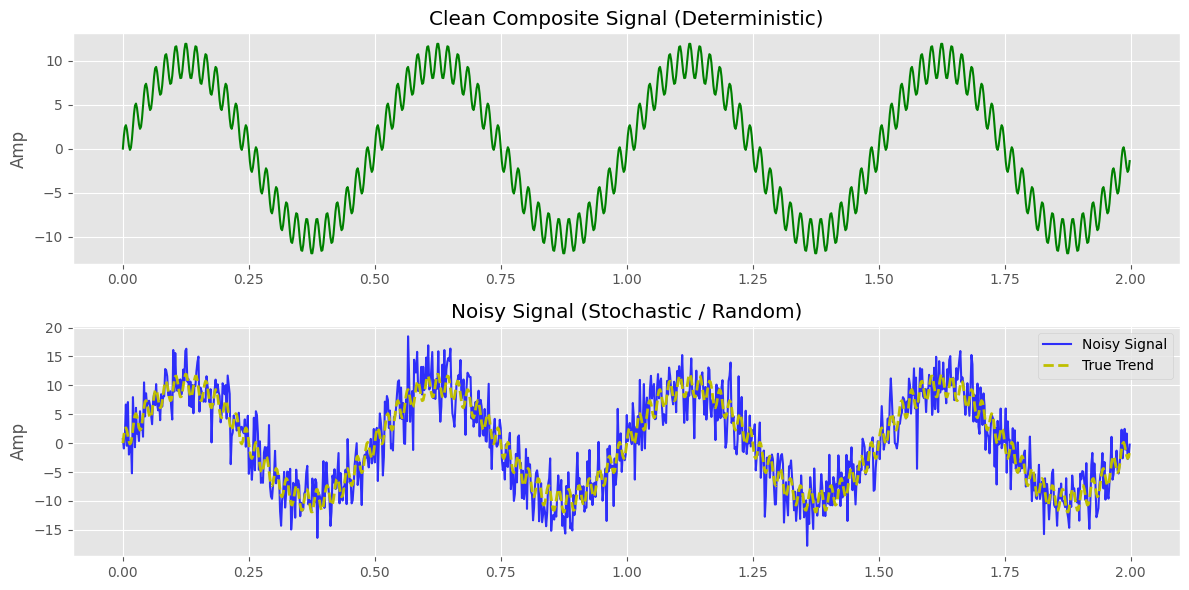

In [6]:
# --- تنظیمات نویز ---
noise_level = 3  # قدرت نویز (انحراف معیار)

# تولید نویز سفید با توزیع نرمال
# میانگین = ۰، انحراف معیار = ۳
noise = np.random.normal(0, noise_level, len(t))

# سیگنال نویزی شده
noisy_signal = composite_signal + noise

# --- رسم نمودار مقایسه‌ای ---
plt.figure(figsize=(12, 6))

# پلات ۱: سیگنال تمیز
plt.subplot(2, 1, 1)
plt.plot(t, composite_signal, 'g')
plt.title('Clean Composite Signal (Deterministic)')
plt.ylabel('Amp')

# پلات ۲: سیگنال نویزی
plt.subplot(2, 1, 2)
plt.plot(t, noisy_signal, 'b', alpha=0.8, label='Noisy Signal')
plt.plot(t, composite_signal, 'y--', linewidth=2, label='True Trend') # روند اصلی
plt.title('Noisy Signal (Stochastic / Random)')
plt.ylabel('Amp')
plt.legend()

plt.tight_layout()
plt.show()

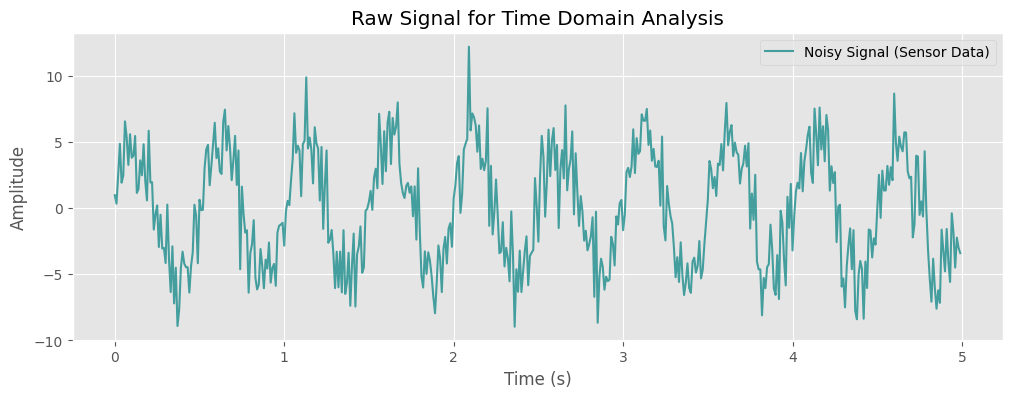

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# تنظیمات اولیه
plt.style.use('ggplot')

# ۱. تولید سیگنال مصنوعی (همانند جلسه قبل)
fs = 100            # فرکانس نمونه‌برداری
duration = 5.0      # ۵ ثانیه
t = np.arange(0, duration, 1/fs)

# سیگنال اصلی (تمیز)
freq = 2  # ۲ هرتز
signal_clean = 5 * np.sin(2 * np.pi * freq * t)

# اضافه کردن نویز (تصادفی)
np.random.seed(42) # برای اینکه نتایج همه دانشجویان یکسان باشد
noise = np.random.normal(0, 2, len(t)) # میانگین ۰ و انحراف ۲
signal_noisy = signal_clean + noise

# نمایش سیگنال
plt.figure(figsize=(12, 4))
plt.plot(t, signal_noisy, label='Noisy Signal (Sensor Data)', color='teal', alpha=0.7)
plt.title('Raw Signal for Time Domain Analysis')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

--- Statistical Features ---
Mean (DC Offset): 0.0137
Variance (Activity Level): 17.6341
Max Peak: 12.2296
Peak-to-Peak Range: 21.1913


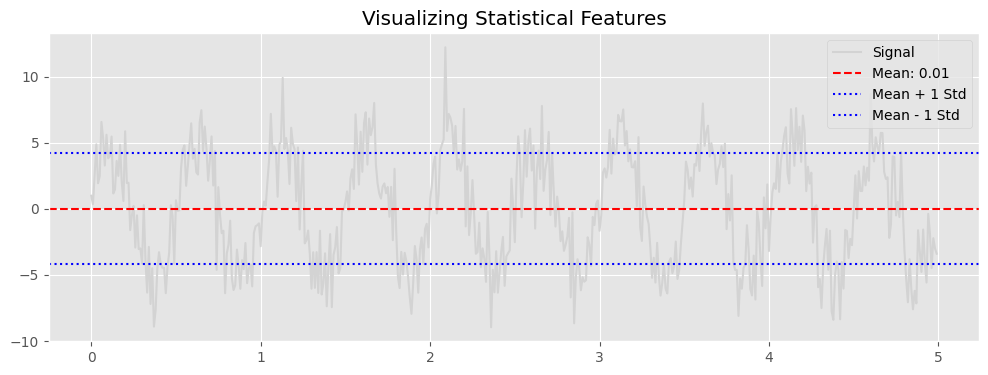

In [8]:
# --- محاسبه ویژگی‌های آماری ---

# ۱. میانگین (Mean) 
# فرمول: (1/N) * sum(x)
mean_val = np.mean(signal_noisy)

# ۲. واریانس و انحراف معیار (Variance & Std) 
# فرمول: (1/N) * sum((x - mean)^2)
variance_val = np.var(signal_noisy)
std_val = np.std(signal_noisy)

# ۳. مقادیر اکسترمم (Min/Max & Peak) 
max_val = np.max(signal_noisy)
min_val = np.min(signal_noisy)

# دامنه پیک-تا-پیک (Peak-to-Peak)
# فرمول: Max - Min
ptp_val = np.ptp(signal_noisy) # یا max_val - min_val

print(f"--- Statistical Features ---")
print(f"Mean (DC Offset): {mean_val:.4f}")
print(f"Variance (Activity Level): {variance_val:.4f}")
print(f"Max Peak: {max_val:.4f}")
print(f"Peak-to-Peak Range: {ptp_val:.4f}")

# --- نمایش روی نمودار (برای درک شهودی) ---
plt.figure(figsize=(12, 4))
plt.plot(t, signal_noisy, color='lightgray', label='Signal')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axhline(mean_val + std_val, color='blue', linestyle=':', label='Mean + 1 Std')
plt.axhline(mean_val - std_val, color='blue', linestyle=':', label='Mean - 1 Std')
plt.legend()
plt.title('Visualizing Statistical Features')
plt.show()

power and energy

In [9]:
# --- ویژگی‌های مبتنی بر انرژی ---

# ۱. انرژی سیگنال (Signal Energy) 
# فرمول: sum(x[n]^2)
energy = np.sum(signal_noisy ** 2)

# ۲. توان سیگنال (Signal Power) 
# فرمول: (1/N) * sum(x[n]^2)  یا همان میانگین مربع‌ها
power = np.mean(signal_noisy ** 2)

# ۳. مقدار موثر (RMS - Root Mean Square) 
# فرمول: sqrt(Power)
rms = np.sqrt(power)

print(f"--- Energy & Power Features ---")
print(f"Energy: {energy:.4f} (Dependent on signal length)")
print(f"Power:  {power:.4f} (Independent of length)")
print(f"RMS:    {rms:.4f} (Effective Amplitude)")



--- Energy & Power Features ---
Energy: 8817.1360 (Dependent on signal length)
Power:  17.6343 (Independent of length)
RMS:    4.1993 (Effective Amplitude)


--- Temporal Pattern Features ---
Total Zero Crossings: 75
Zero Crossing Rate (Hz): 15.00


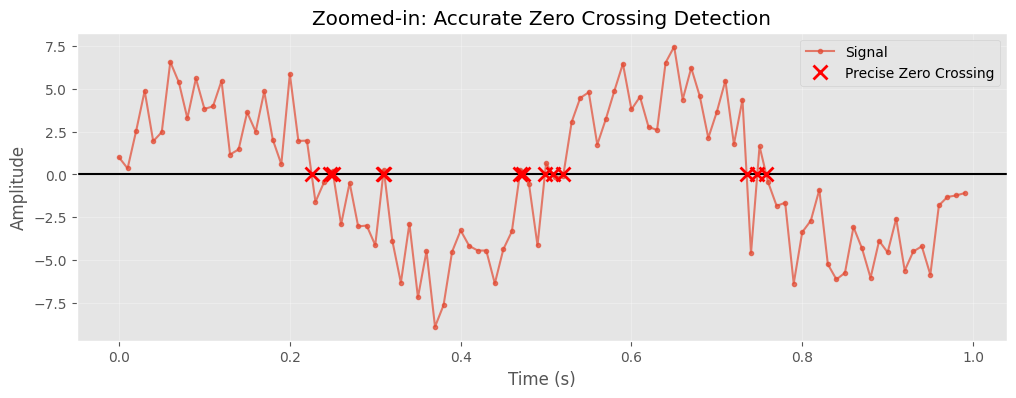

In [10]:
# --- نرخ عبور از صفر (ZCR) ---

# روش برداری و دقیق (Vectorized)
# ۱. استفاده از signbit برای سرعت و دقت بالاتر در تشخیص تغییر علامت
# ۲. np.diff تغییرات را پیدا می‌کند (True یعنی علامت تغییر کرده)
zcr_indices = np.where(np.diff(np.signbit(signal_noisy)))[0]
zcr_count = len(zcr_indices)

# محاسبه نرخ (Rate)
zcr_rate = zcr_count / duration  # تعداد عبور در ثانیه (Hz)

print(f"--- Temporal Pattern Features ---")
print(f"Total Zero Crossings: {zcr_count}")
print(f"Zero Crossing Rate (Hz): {zcr_rate:.2f}")

# --- نمایش دقیق نقاط عبور از صفر (با اصلاح بصری) ---
plt.figure(figsize=(12, 4))

# زوم کردن روی ۱۰۰ نمونه اول برای وضوح بیشتر
zoom_range = 100
plt.plot(t[:zoom_range], signal_noisy[:zoom_range], label='Signal', marker='.', alpha=0.7)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # خط مبنای صفر

# فیلتر کردن ایندکس‌های تقاطع که در بازه زوم هستند
zoom_indices = zcr_indices[zcr_indices < zoom_range - 1]

# محاسبه محل دقیق زمانی که سیگنال صفر می‌شود (درونیابی خطی)
# فرمول: t_zero = t1 - y1 * (dt / dy)
t_crossings = []
for i in zoom_indices:
    t1, t2 = t[i], t[i+1]
    y1, y2 = signal_noisy[i], signal_noisy[i+1]
    # پیدا کردن زمان دقیق صفر شدن بین دو نقطه
    t_zero = t1 - y1 * ((t2 - t1) / (y2 - y1))
    t_crossings.append(t_zero)

# رسم ضربدرها دقیقاً روی خط صفر (y=0)
plt.plot(t_crossings, np.zeros_like(t_crossings), 'rx', 
         markersize=10, markeredgewidth=2, label='Precise Zero Crossing', zorder=5)

plt.title('Zoomed-in: Accurate Zero Crossing Detection')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()